🖥️ Usando dispositivo: cpu
📂 Carregando configurações do dataset...
✅ Configurações carregadas com sucesso!
📊 Criando DataLoaders...
✅ DataLoaders criados em 0.00 segundos.
📦 Criando modelo Faster R-CNN...
✅ Modelo criado em 0.27 segundos.
🚀 Iniciando treinamento...
🟢 Batch 1/350 - Loss: 3.0837
🟢 Batch 2/350 - Loss: 2.2206
🟢 Batch 3/350 - Loss: 0.8421
🟢 Batch 4/350 - Loss: 0.6720
🟢 Batch 5/350 - Loss: 0.8022
🟢 Batch 6/350 - Loss: 0.4022
🟢 Batch 7/350 - Loss: 0.2897
🟢 Batch 8/350 - Loss: 0.3474
🟢 Batch 9/350 - Loss: 1.2917
🟢 Batch 10/350 - Loss: 0.3429
🟢 Batch 11/350 - Loss: 0.3930
🟢 Batch 12/350 - Loss: 0.1567
🟢 Batch 13/350 - Loss: 0.7427
🟢 Batch 14/350 - Loss: 0.4542
🟢 Batch 15/350 - Loss: 0.6186
🟢 Batch 16/350 - Loss: 0.1531
🟢 Batch 17/350 - Loss: 0.3692
🟢 Batch 18/350 - Loss: 0.2625
🟢 Batch 19/350 - Loss: 1.1566
🟢 Batch 20/350 - Loss: 0.4469
🟢 Batch 21/350 - Loss: 0.3747
🟢 Batch 22/350 - Loss: 0.3521
🟢 Batch 23/350 - Loss: 0.3224
🟢 Batch 24/350 - Loss: 0.4880
🟢 Batch 25/350 - Loss:

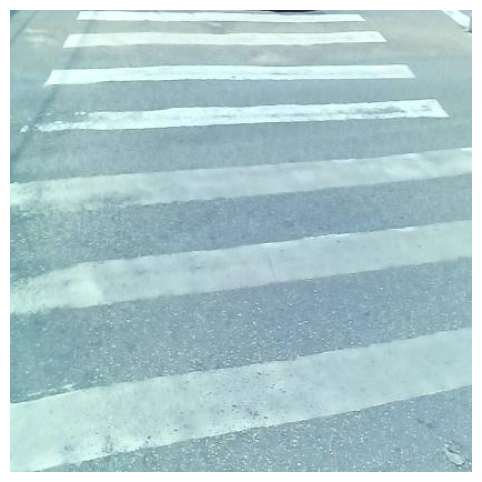

🟡 Testando imagem: i1045.jpg


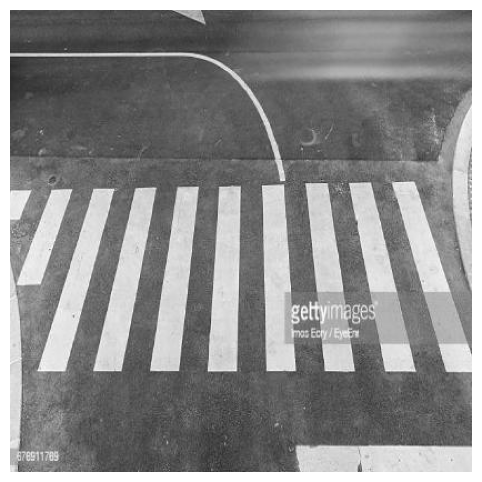

🟡 Testando imagem: i1051.jpg


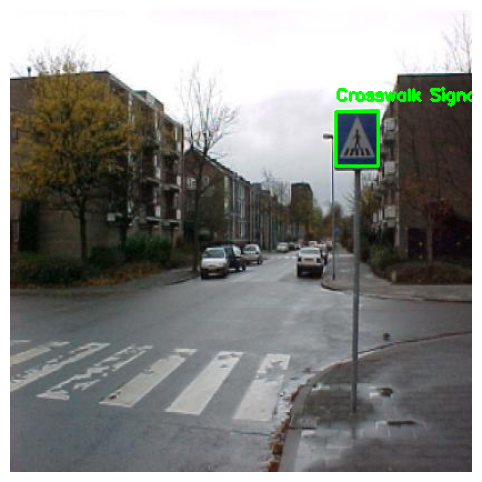

✅ Teste finalizado!


In [8]:
import os
import time
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import cv2
import yaml
from PIL import Image
import matplotlib.pyplot as plt

# Configuração do dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\U0001F5A5️ Usando dispositivo: {device}")

# Carregar configurações do dataset
print("\U0001F4C2 Carregando configurações do dataset...")
with open("dataset.yaml", "r") as file:
    dataset_config = yaml.safe_load(file)

train_dir = dataset_config["train"]
val_dir = dataset_config["val"]
nc = dataset_config["nc"]
class_names = dataset_config["names"]
print("✅ Configurações carregadas com sucesso!")

class ObjectDetectionDataset(Dataset):
    def __init__(self, image_dir, transform=None, limit=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_filenames = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])[:limit]
        self.label_dir = image_dir.replace("images", "labels")

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        label_path = os.path.join(self.label_dir, self.image_filenames[idx].replace(".png", ".txt"))

        if not os.path.exists(label_path):
            print(f"⚠️ Aviso: {label_path} não encontrado! Pulando esta imagem.")
            return None

        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        with open(label_path, "r") as f:
            boxes = []
            labels = []
            for line in f.readlines():
                parts = list(map(float, line.strip().split()))
                if len(parts) != 5:
                    continue  # Ignora rótulos corrompidos
                class_id, x, y, w, h = parts
                x_min = (x - w / 2) * width
                y_min = (y - h / 2) * height
                x_max = (x + w / 2) * width
                y_max = (y + h / 2) * height
                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(int(class_id))

        if len(boxes) == 0:
            print(f"⚠️ Aviso: Nenhum objeto encontrado em {label_path}. Pulando esta imagem.")
            return None

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        if self.transform:
            image = self.transform(image)

        return image, target

# Função para remover itens None do DataLoader
def collate_fn(batch):
    batch = [b for b in batch if b is not None]  # Remove imagens sem bounding boxes
    return tuple(zip(*batch)) if batch else ([], [])

# Transformações
transform = transforms.Compose([transforms.ToTensor()])

print("\U0001F4CA Criando DataLoaders...")
start_time = time.time()
train_dataset = ObjectDetectionDataset(train_dir, transform=transform)
val_dataset = ObjectDetectionDataset(val_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
print(f"✅ DataLoaders criados em {time.time() - start_time:.2f} segundos.")

# Criar modelo Faster R-CNN
print("📦 Criando modelo Faster R-CNN...")
start_time = time.time()
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, nc + 1)
model.to(device)
print(f"✅ Modelo criado em {time.time() - start_time:.2f} segundos.")

# Definir otimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 1  # Apenas 1 época para teste rápido

# Treinamento
print("🚀 Iniciando treinamento...")
start_time = time.time()
model.train()

for epoch in range(num_epochs):
    epoch_start = time.time()
    total_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):
        if not images:  # Skip empty batches
            continue

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        print(f"🟢 Batch {batch_idx + 1}/{len(train_loader)} - Loss: {loss.item():.4f}")

    print(f"✅ Época {epoch + 1}/{num_epochs} finalizada. Loss Total: {total_loss:.4f} - Tempo da época: {time.time() - epoch_start:.2f}s")

print(f"⏳ Tempo total de treinamento: {time.time() - start_time:.2f} segundos.")

# Função para testar uma imagem
def test_image(image_path):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(image_tensor)

    image = cv2.imread(image_path)
    for i, box in enumerate(prediction[0]["boxes"]):
        x_min, y_min, x_max, y_max = box.cpu().numpy().astype(int)
        label = int(prediction[0]["labels"][i].cpu().numpy())
        confidence = prediction[0]["scores"][i].cpu().numpy()
        if confidence > 0.5:
            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
            cv2.putText(image, f"{class_names[label]}: {confidence:.2f}", (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Teste rápido do modelo
print("🖼️ Testando algumas imagens...")
valid_images = sorted([f for f in os.listdir(val_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])[:3]

if not valid_images:
    print("⚠️ Nenhuma imagem válida encontrada para teste!")
else:
    for img_name in valid_images:
        print(f"🟡 Testando imagem: {img_name}")
        test_image(os.path.join(val_dir, img_name))

print("✅ Teste finalizado!")


In [ ]:
import os
import time
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import cv2
import yaml
from PIL import Image
import matplotlib.pyplot as plt

# Configuração do dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Usando dispositivo: {device}")

# Carregar configurações do dataset
print("📂 Carregando configurações do dataset...")
with open("dataset.yaml", "r") as file:
    dataset_config = yaml.safe_load(file)

train_dir = dataset_config["train"]
val_dir = dataset_config["val"]
nc = dataset_config["nc"]
class_names = dataset_config["names"]
print("✅ Configurações carregadas com sucesso!")

class ObjectDetectionDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_filenames = sorted([f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
        self.label_dir = image_dir.replace("images", "labels")

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        label_path = os.path.join(self.label_dir, self.image_filenames[idx].replace(".png", ".txt").replace(".jpg", ".txt").replace(".jpeg", ".txt"))

        if not os.path.exists(label_path):
            print(f"⚠️ Aviso: {label_path} não encontrado! Pulando esta imagem.")
            return None

        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        with open(label_path, "r") as f:
            boxes = []
            labels = []
            for line in f.readlines():
                parts = list(map(float, line.strip().split()))
                if len(parts) != 5:
                    continue  # Ignora rótulos corrompidos
                class_id, x, y, w, h = parts
                x_min = (x - w / 2) * width
                y_min = (y - h / 2) * height
                x_max = (x + w / 2) * width
                y_max = (y + h / 2) * height
                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(int(class_id))

        if len(boxes) == 0:
            print(f"⚠️ Aviso: Nenhum objeto encontrado em {label_path}. Pulando esta imagem.")
            return None

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        if self.transform:
            image = self.transform(image)

        return image, target

# Função para remover itens None do DataLoader
def collate_fn(batch):
    batch = [b for b in batch if b is not None]  # Remove imagens sem bounding boxes
    return tuple(zip(*batch)) if batch else ([], [])

# Transformações
transform = transforms.Compose([transforms.ToTensor()])

print("📊 Criando DataLoaders...")
start_time = time.time()
train_dataset = ObjectDetectionDataset(train_dir, transform=transform)
val_dataset = ObjectDetectionDataset(val_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
print(f"✅ DataLoaders criados em {time.time() - start_time:.2f} segundos.")

# Criar modelo Faster R-CNN
print("📦 Criando modelo Faster R-CNN...")
start_time = time.time()
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, nc + 1)
model.to(device)
print(f"✅ Modelo criado em {time.time() - start_time:.2f} segundos.")

# Definir otimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 5  # Agora treinamos por 5 épocas

# Treinamento
print("🚀 Iniciando treinamento...")
start_time = time.time()
model.train()

for epoch in range(num_epochs):
    epoch_start = time.time()
    total_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):
        if not images:  # Skip empty batches
            continue

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 10 == 0:  # Mostra logs a cada 10 batches
            print(f"🟢 Batch {batch_idx + 1}/{len(train_loader)} - Loss: {loss.item():.4f}")

    print(f"✅ Época {epoch + 1}/{num_epochs} finalizada. Loss Total: {total_loss:.4f} - Tempo da época: {time.time() - epoch_start:.2f}s")

print(f"⏳ Tempo total de treinamento: {time.time() - start_time:.2f} segundos.")

# Salvar modelo treinado
torch.save(model.state_dict(), "faster_rcnn_model.pth")
print("💾 Modelo salvo com sucesso!")

# Função para testar uma imagem
def test_image(image_path, confidence_threshold=0.6):  # Ajustamos o threshold para evitar falsas detecções
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(image_tensor)

    image = cv2.imread(image_path)
    for i, box in enumerate(prediction[0]["boxes"]):
        confidence = prediction[0]["scores"][i].cpu().numpy()
        if confidence > confidence_threshold:
            x_min, y_min, x_max, y_max = box.cpu().numpy().astype(int)
            label = int(prediction[0]["labels"][i].cpu().numpy())

            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
            cv2.putText(image, f"{class_names[label]}: {confidence:.2f}", (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Teste rápido do modelo
print("🖼️ Testando algumas imagens...")
valid_images = sorted([f for f in os.listdir(val_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])[:3]

if not valid_images:
    print("⚠️ Nenhuma imagem válida encontrada para teste!")
else:
    for img_name in valid_images:
        print(f"🟡 Testando imagem: {img_name}")
        test_image(os.path.join(val_dir, img_name), confidence_threshold=0.6)

print("✅ Teste finalizado!")
